# Control Twin Lab — visualize Track B sims

**This is not the hybrid IdealLoads playground.**  
It plots **W2A Control Twin Lab** smoke runs (`SYNTHETIC_W2A_PROVENANCE` / `NON_PROMOTABLE`).

- Stages A04 copies (never overwrites champion)
- Smoke profile uses a deterministic plant synthesizer when EnergyPlus CSV is absent
- **Not** Lakeside field compressor kW · **not** Track A sensors

Run all cells. If lab artifacts are missing, the setup cell re-runs `--profile smoke`.

In [1]:
%matplotlib inline
from datetime import datetime
print("KERNEL ALIVE", datetime.now().isoformat(timespec="seconds"), flush=True)

import json, os, sys, subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path("..").resolve()
if not (ROOT / "ml").is_dir():
    ROOT = Path(".").resolve()
sys.path[:0] = [str(ROOT), str(ROOT / "ml"), str(ROOT / "scripts")]

from notebook_plots import apply_notebook_theme, save_fig
apply_notebook_theme()

SITE = Path(os.environ.get("LAKESIDE_SITE_ROOT", r"C:\Users\ben\OneDrive\Desktop\testing\sp_creekside"))
os.environ["LAKESIDE_SITE_ROOT"] = str(SITE)

LAB = ROOT / "ml" / "artifacts" / "w2a_dsm_lab"
REP_ML = ROOT / "reports" / "ml"
REP_EP = ROOT / "reports" / "eplus"
FIG = ROOT / "reports" / "figures" / "control_twin_lab"
FIG.mkdir(parents=True, exist_ok=True)

need = [
    LAB / "runs" / "baseline_pr0" / "plant_15min.parquet",
    LAB / "runs" / "stagger_preheat_pr0" / "plant_15min.parquet",
    REP_ML / "dsm_treatment_scorecard.csv",
]
if not all(p.is_file() for p in need):
    print("Lab artifacts missing — running smoke lab…", flush=True)
    subprocess.check_call(
        [sys.executable, "-u", str(ROOT / "scripts" / "run_control_twin_lab.py"), "--profile", "smoke"],
        cwd=str(ROOT),
    )

summary = json.loads((LAB / "lab_summary.json").read_text(encoding="utf-8"))
card = json.loads((REP_ML / "w2a_plant_electric_surrogate_card.json").read_text(encoding="utf-8"))
treat = pd.read_csv(REP_ML / "dsm_treatment_scorecard.csv")
spin = pd.read_csv(REP_EP / "spinup_sensitivity.csv")
ts = pd.read_csv(REP_EP / "timestep_sensitivity.csv")

display(Markdown(
    f"### Honesty\n"
    f"- provenance: `{summary.get('provenance')}`  \n"
    f"- promote: `{summary.get('promote')}`  \n"
    f"- cases: **{summary.get('n_cases')}** · surrogate holdout MAE ≈ **{summary.get('surrogate_holdout_mae_kw'):.2f} kW**\n"
    f"- site: `{SITE}`"
))
print("SETUP COMPLETE", flush=True)

KERNEL ALIVE 2026-08-10T12:55:02


### Honesty
- provenance: `SYNTHETIC_W2A_PROVENANCE`  
- promote: `NON_PROMOTABLE`  
- cases: **2** · surrogate holdout MAE ≈ **1.55 kW**
- site: `C:\Users\ben\OneDrive\Desktop\testing\sp_creekside`

SETUP COMPLETE


## 1 · Plant electric day (baseline vs stagger preheat)

96 × 15‑min `p_hvac_kw` from lab runs. Synthetic smoke unless you dropped real E+ CSVs into the run folders.

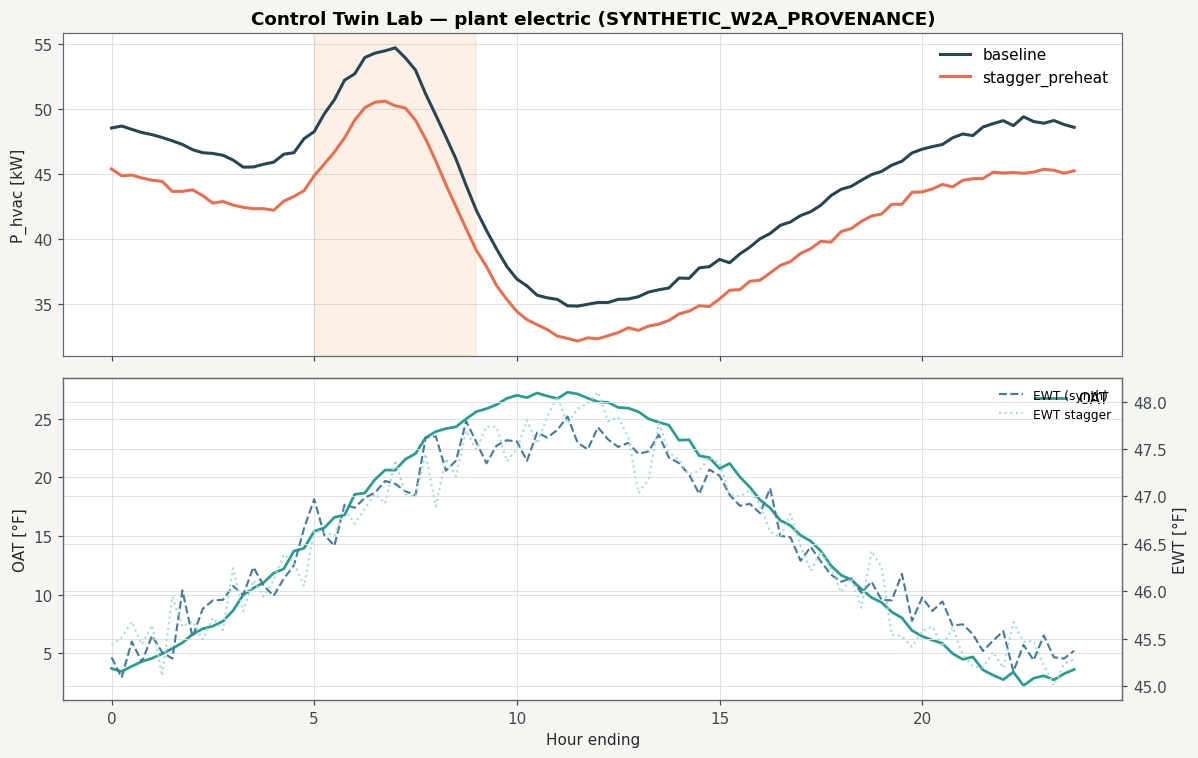

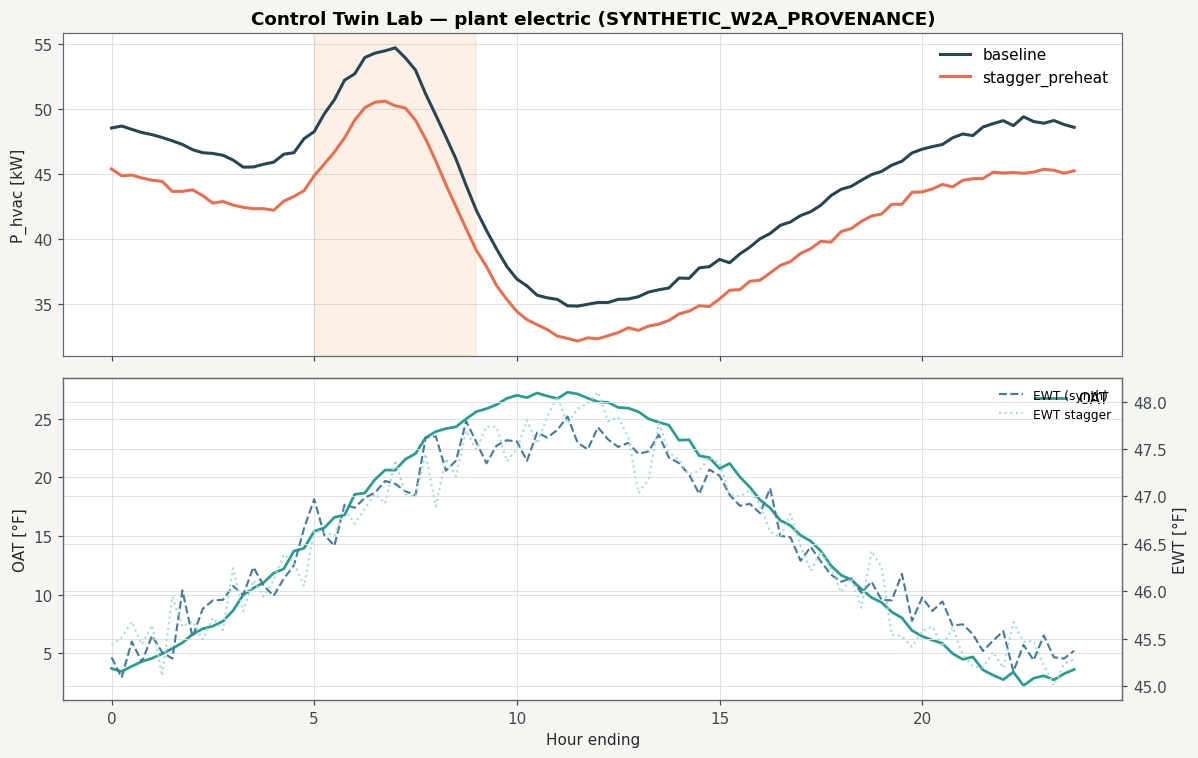

baseline peak 54.7095253450364 kW
stagger  peak 50.60409821543314 kW
source synthetic_smoke_generator


In [2]:
def load_run(tag: str) -> pd.DataFrame:
    p = LAB / "runs" / tag / "plant_15min.parquet"
    df = pd.read_parquet(p)
    df["hour"] = df["timestamp_step"].astype(float) * 0.25
    return df

base = load_run("baseline_pr0")
stag = load_run("stagger_preheat_pr0")

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax = axes[0]
ax.plot(base["hour"], base["p_hvac_kw"], label="baseline", color="#264653", lw=2)
ax.plot(stag["hour"], stag["p_hvac_kw"], label="stagger_preheat", color="#e76f51", lw=2)
ax.set_ylabel("P_hvac [kW]")
ax.set_title("Control Twin Lab — plant electric (SYNTHETIC_W2A_PROVENANCE)")
ax.legend(frameon=False)
ax.axvspan(5, 9, color="#f4a261", alpha=0.15, label="morning window")

ax = axes[1]
ax.plot(base["hour"], base["oat_f"], color="#2a9d8f", lw=1.8, label="OAT")
ax.set_ylabel("OAT [°F]")
ax.set_xlabel("Hour ending")
ax.legend(frameon=False)
ax2 = ax.twinx()
ax2.plot(base["hour"], base["ewt_f"], color="#457b9d", ls="--", lw=1.4, label="EWT (synth)")
ax2.plot(stag["hour"], stag["ewt_f"], color="#a8dadc", ls=":", lw=1.4, label="EWT stagger")
ax2.set_ylabel("EWT [°F]")
ax2.legend(loc="upper right", frameon=False, fontsize=8)

fig.tight_layout()
save_fig(FIG / "ctl_lab_plant_day.png", fig)
plt.show()

print("baseline peak", float(base["p_hvac_kw"].max()), "kW")
print("stagger  peak", float(stag["p_hvac_kw"].max()), "kW")
print("source", base["source"].iloc[0] if "source" in base.columns else "?")

## 2 · Stacked plant components (baseline)

Heat coil / fan / pump breakdown — still synthetic lab, not meter.

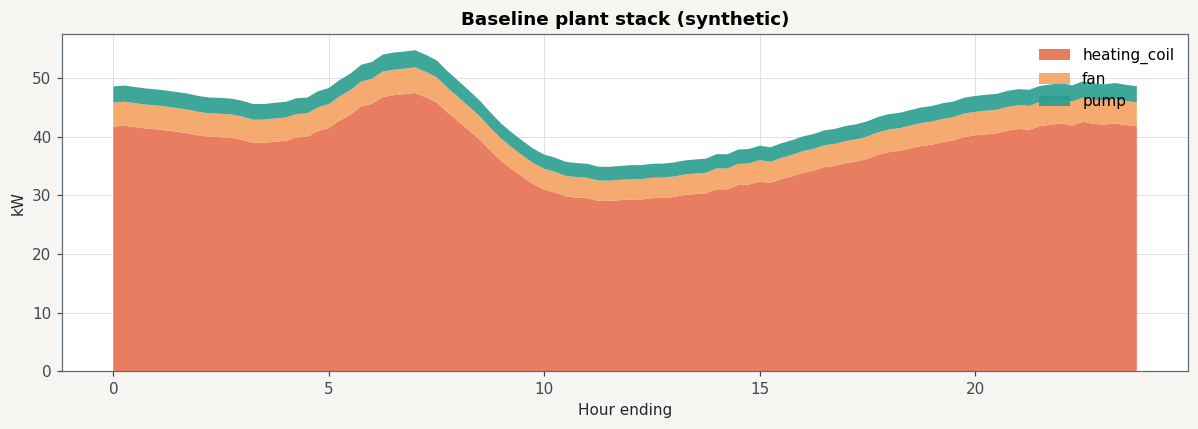

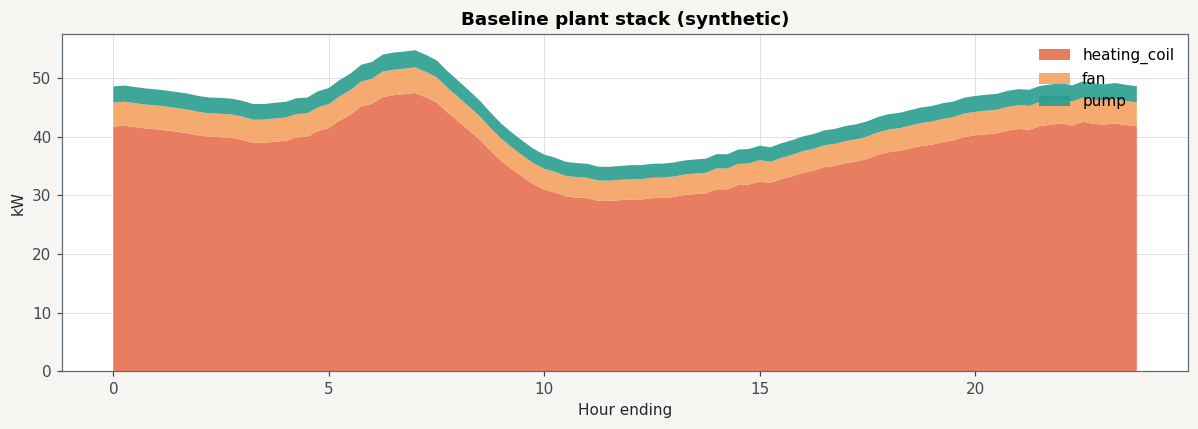

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
h = base["hour"].to_numpy()
ax.stackplot(
    h,
    base["heating_coil_kw"],
    base["fan_kw"],
    base["pump_kw"],
    labels=["heating_coil", "fan", "pump"],
    colors=["#e76f51", "#f4a261", "#2a9d8f"],
    alpha=0.9,
)
ax.set_xlabel("Hour ending")
ax.set_ylabel("kW")
ax.set_title("Baseline plant stack (synthetic)")
ax.legend(loc="upper right", frameon=False)
fig.tight_layout()
save_fig(FIG / "ctl_lab_plant_stack.png", fig)
plt.show()

## 3 · Treatment scorecard + spin / timestep tables

Δpeak / ΔkWh vs baseline from the lab. Smoke only filled spin=0 and timestep=6.

### Treatment (vs baseline)

,eval_day,strategy,baseline_peak_kw,strategy_peak_kw,delta_peak_kw,baseline_kwh,strategy_kwh,delta_kwh,sign_peak_reduction,provenance,honesty,promote,note
0,2026-01-26,stagger_preheat,54.709525,50.604098,-4.105427,1064.751081,986.544561,-78.20652,True,SYNTHETIC_W2A_PROVENANCE,CONTROL_TWIN_LAB_V1,NON_PROMOTABLE,SYNTHETIC_W2A_PROVENANCE treatment deltas — no...


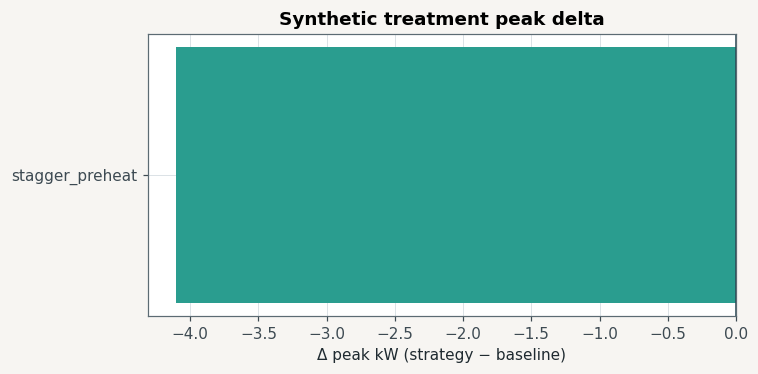

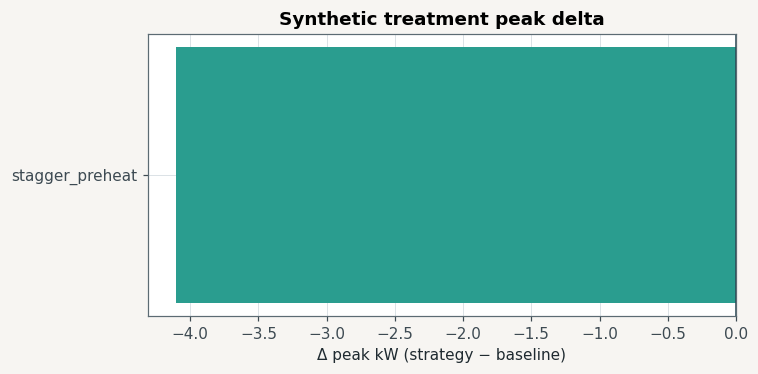

### Spin-up sensitivity

,eval_day,pre_roll_days,daily_kwh,peak_kw,peak_step,zone_mae_vs_pr7,ewt_mean,note,glhe_seasonal_ok,recommendation,provenance,physics_family
0,2026-01-26,0,1025.647821,54.709525,NaN,NaN,46.516674,CONTROL_TWIN_LAB filled n=2; short pre-roll ≠ ...,False,LAB_FILLED,SYNTHETIC_W2A_PROVENANCE,W2A_PHYSICAL_DSM
1,2026-01-26,3,NaN,NaN,NaN,NaN,NaN,No case at this pre_roll in profile — run --pr...,False,MISSING_IN_PROFILE,SYNTHETIC_W2A_PROVENANCE,W2A_PHYSICAL_DSM
2,2026-01-26,7,NaN,NaN,NaN,NaN,NaN,No case at this pre_roll in profile — run --pr...,False,MISSING_IN_PROFILE,SYNTHETIC_W2A_PROVENANCE,W2A_PHYSICAL_DSM
3,2026-01-26,14,NaN,NaN,NaN,NaN,NaN,No case at this pre_roll in profile — run --pr...,False,MISSING_IN_PROFILE,SYNTHETIC_W2A_PROVENANCE,W2A_PHYSICAL_DSM


### Timestep sensitivity

,eval_day,zone_timesteps_per_hour,physics_family,daily_kwh,peak_kw,peak_step,hvac_iter_warnings,staged_idf,note,provenance
0,2026-01-26,4,W2A_PHYSICAL_DSM,NaN,NaN,NaN,NaN,NaN,No case at this timestep in profile — run --pr...,SYNTHETIC_W2A_PROVENANCE
1,2026-01-26,6,W2A_PHYSICAL_DSM,1025.647821,54.709525,NaN,NaN,C:\Users\ben\Documents\py-bacnet-stacks-playgr...,CONTROL_TWIN_LAB filled n=2,SYNTHETIC_W2A_PROVENANCE
2,2026-01-26,12,W2A_PHYSICAL_DSM,NaN,NaN,NaN,NaN,NaN,No case at this timestep in profile — run --pr...,SYNTHETIC_W2A_PROVENANCE


In [4]:
display(Markdown("### Treatment (vs baseline)"))
display(treat)

if len(treat) and "delta_peak_kw" in treat.columns:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    colors = ["#2a9d8f" if v < 0 else "#e76f51" for v in treat["delta_peak_kw"]]
    ax.barh(treat["strategy"].astype(str), treat["delta_peak_kw"], color=colors)
    ax.axvline(0, color="#264653", lw=1)
    ax.set_xlabel("Δ peak kW (strategy − baseline)")
    ax.set_title("Synthetic treatment peak delta")
    fig.tight_layout()
    save_fig(FIG / "ctl_lab_treatment_delta.png", fig)
    plt.show()

display(Markdown("### Spin-up sensitivity"))
display(spin)
display(Markdown("### Timestep sensitivity"))
display(ts)

## 4 · Surrogate card

Small sklearn map trained on lab trajectories only.

In [5]:
display(Markdown("```json\n" + json.dumps(card, indent=2) + "\n```"))
assert card.get("provenance") == "SYNTHETIC_W2A_PROVENANCE"
assert card.get("promote") == "NON_PROMOTABLE"
print("surrogate OK — non-promotable synthetic")

```json
{
  "run_id": "w2a_plant_surr_20260810T174426Z",
  "honesty": "CONTROL_TWIN_LAB_V1",
  "provenance": "SYNTHETIC_W2A_PROVENANCE",
  "promote": "NON_PROMOTABLE",
  "physics_family": "W2A_PHYSICAL_DSM",
  "n_rows": 192,
  "n_train": 153,
  "holdout_mae_kw": 1.5516810895443574,
  "feature_cols": [
    "oat_f",
    "hdd65",
    "timestamp_step",
    "sin_step",
    "cos_step",
    "pre_roll_days",
    "steps_per_hour",
    "strategy_baseline",
    "strategy_stagger_preheat",
    "strategy_deep_setback",
    "strategy_flat_24_7",
    "strategy_prbs"
  ],
  "note": "SYNTHETIC_W2A_PROVENANCE \u2014 trained on Control Twin Lab trajectories (staged A04 / smoke synthesizer). NOT Lakeside field compressor kW. NON_PROMOTABLE."
}
```

surrogate OK — non-promotable synthetic


## Next

- More curves: `python -u scripts/run_control_twin_lab.py --profile full_lab` (longer)
- Real E+: drop EnergyPlus variable CSVs into `ml/artifacts/w2a_dsm_lab/runs/<tag>/` then re-run extract
- Track A sensors: still `docs/audits/plant_point_candidates.md`
- Hybrid IdealLoads playground (different stack): `lakeside_desktop_sim_playground.ipynb`